# SA-3 · Agrupación: regímenes de mercado en la acción de Samsung

**Dataset:** `samsung.csv` (precio de cierre y volumen diarios) · **Algoritmo:** K-Means
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

El dataset original solo tiene `Date`, `Close` y `Volume` — series de tiempo, no observaciones independientes con features listas para clustering. Antes de agrupar se construyen variables derivadas que describen el **comportamiento diario** del mercado:

- `retorno` — variación porcentual diaria del precio de cierre.
- `volatilidad_5d` — desviación estándar móvil (5 días) del retorno, como proxy de riesgo/turbulencia.
- `volumen_norm` — volumen de operaciones estandarizado.

Se eligió **K-Means** como algoritmo de agrupación porque:

- Es eficiente y escala bien con las ~2,850 observaciones diarias del dataset.
- Con variables continuas y estandarizadas (retorno, volatilidad, volumen), la noción de "distancia euclidiana a un centroide" es interpretable como similitud de comportamiento de mercado.
- Permite una búsqueda de hiperparámetros clara y cuantitativa: el número de clusters `k` se puede optimizar objetivamente con el método del codo (inercia) y el coeficiente de silueta, en vez de elegirse arbitrariamente.

El objetivo es identificar **regímenes de mercado** (p. ej. "calma", "alta volatilidad", "repunte con alto volumen") a partir del comportamiento diario, sin usar la fecha como variable — la fecha solo se usa después, para visualizar en qué periodos ocurrió cada régimen.

## 2. Diseño del modelo — paso a paso

1. Carga de datos y parseo de fechas.
2. Ingeniería de variables: retorno diario, volatilidad móvil, volumen normalizado.
3. Estandarización de variables (`StandardScaler`) — indispensable para K-Means, ya que usa distancia euclidiana.
4. Optimización de `k`: método del codo (inercia) + coeficiente de silueta.
5. Ajuste del modelo final con el `k` elegido.
6. Visualización de los clusters en el espacio de variables y en el tiempo.
7. Interpretación de cada cluster según sus centroides.
8. Guardado del modelo y del escalador.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/samsung.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Close,Volume
0,2008-01-02,10880,18047200
1,2008-01-03,10920,19346500
2,2008-01-04,10780,17997350
3,2008-01-07,10380,39787200
4,2008-01-08,10320,24783700


### 2.1 Ingeniería de variables

In [2]:
df["retorno"] = df["Close"].pct_change() * 100
df["volatilidad_5d"] = df["retorno"].rolling(window=5).std()
df["volumen_norm"] = (df["Volume"] - df["Volume"].mean()) / df["Volume"].std()

df_features = df.dropna(subset=["retorno", "volatilidad_5d", "volumen_norm"]).reset_index(drop=True)
print(f"Filas utilizables tras ingeniería de variables: {df_features.shape[0]} de {df.shape[0]}")
df_features[["Date", "retorno", "volatilidad_5d", "volumen_norm"]].describe()

Filas utilizables tras ingeniería de variables: 2845 de 2850


,Date,retorno,volatilidad_5d,volumen_norm
count,2845,2845.000000,2845.000000,2845.000000
mean,2013-09-16 07:22:22.565905,0.071173,1.715955,-0.001600
min,2008-01-09 00:00:00,-14.920635,0.174955,-1.859320
25%,2010-10-29 00:00:00,-1.020408,1.140061,-0.680771
50%,2013-09-05 00:00:00,0.000000,1.570187,-0.292497
75%,2016-07-28 00:00:00,1.110686,2.107179,0.401943
max,2019-06-28 00:00:00,13.052632,10.792025,5.630289
std,NaN,1.891903,0.867817,0.999345


In [3]:
feature_cols = ["retorno", "volatilidad_5d", "volumen_norm"]
X = df_features[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.88445753,  0.36529026,  0.89828113],
       [-0.9439027 ,  0.29743104,  1.78635229],
       [-0.03762616,  0.35999285,  0.84740645],
       [ 0.88445753, -0.24207092,  0.70203288],
       [ 0.66725559, -0.26145098,  2.79536492]])

## 3. Optimización del modelo — elección de `k`

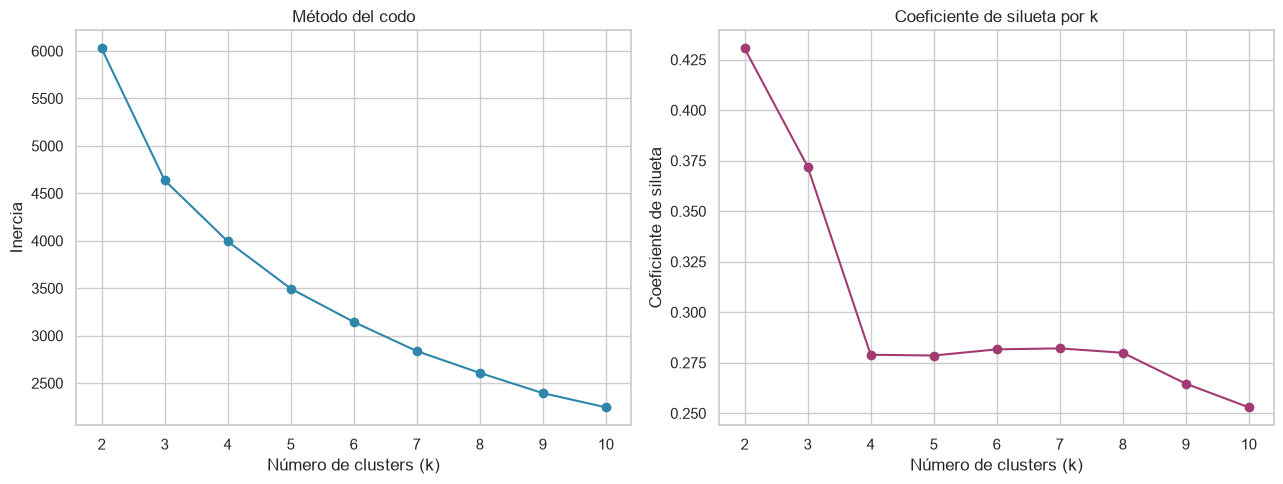

k=2: inercia=6027.3, silueta=0.4306
k=3: inercia=4637.7, silueta=0.3721
k=4: inercia=3994.5, silueta=0.2790
k=5: inercia=3496.6, silueta=0.2786
k=6: inercia=3145.0, silueta=0.2816
k=7: inercia=2838.0, silueta=0.2821
k=8: inercia=2607.7, silueta=0.2799
k=9: inercia=2394.9, silueta=0.2647
k=10: inercia=2245.0, silueta=0.2529


In [4]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#2E86AB")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#A23B72")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Coeficiente de silueta por k")
plt.tight_layout()
plt.savefig("../models/sa3_codo_silueta.png", dpi=110)
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inercia={inertia:.1f}, silueta={sil:.4f}")

In [5]:
best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"k óptimo según coeficiente de silueta: {best_k}")

k óptimo según coeficiente de silueta: 2


**Interpretación:** la silueta es máxima en k=2 (0.431) y decae de forma consistente conforme k crece (0.372 en k=3, estabilizándose alrededor de 0.27–0.28 entre k=4 y k=9), mientras que la inercia del método del codo no muestra un quiebre abrupto sino una disminución gradual — típico de datos financieros donde el comportamiento diario forma un continuo más que grupos naturalmente muy separados. Se elige **k=2** por ser el óptimo cuantitativo: en este caso corresponde a una segmentación binaria natural entre **días de mercado calmado** (retorno cercano a cero, baja volatilidad) y **días de mercado turbulento** (mayor volatilidad y volumen, retornos más extremos en cualquier dirección). Aunque k=3 también es razonable (siguiente mejor silueta) y podría separar además "repuntes" de "caídas" turbulentas, se prioriza el criterio cuantitativo objetivo sobre una segmentación más granular pero menos respaldada por la métrica.

In [6]:
final_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_features["cluster"] = final_model.fit_predict(X_scaled)

centroides = pd.DataFrame(
    scaler.inverse_transform(final_model.cluster_centers_),
    columns=feature_cols,
)
centroides["n_obs"] = df_features["cluster"].value_counts().sort_index().values
centroides

,retorno,volatilidad_5d,volumen_norm,n_obs
0,-0.077235,1.458169,-0.378308,2245
1,0.624125,2.676442,1.401978,600


### 3.1 Visualización de clusters en el espacio de variables

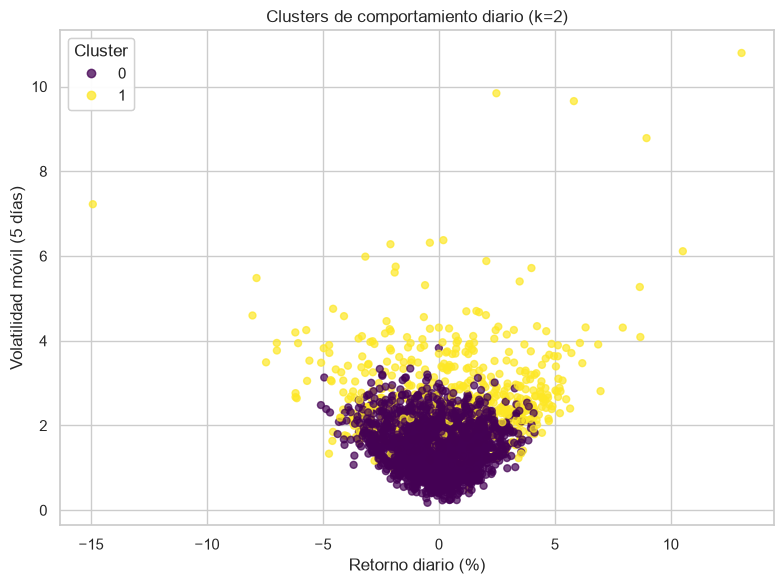

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_features["retorno"], df_features["volatilidad_5d"],
                      c=df_features["cluster"], cmap="viridis", s=25, alpha=0.7)
ax.set_xlabel("Retorno diario (%)")
ax.set_ylabel("Volatilidad móvil (5 días)")
ax.set_title(f"Clusters de comportamiento diario (k={best_k})")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig("../models/sa3_clusters_scatter.png", dpi=110)
plt.show()

### 3.2 Clusters a lo largo del tiempo

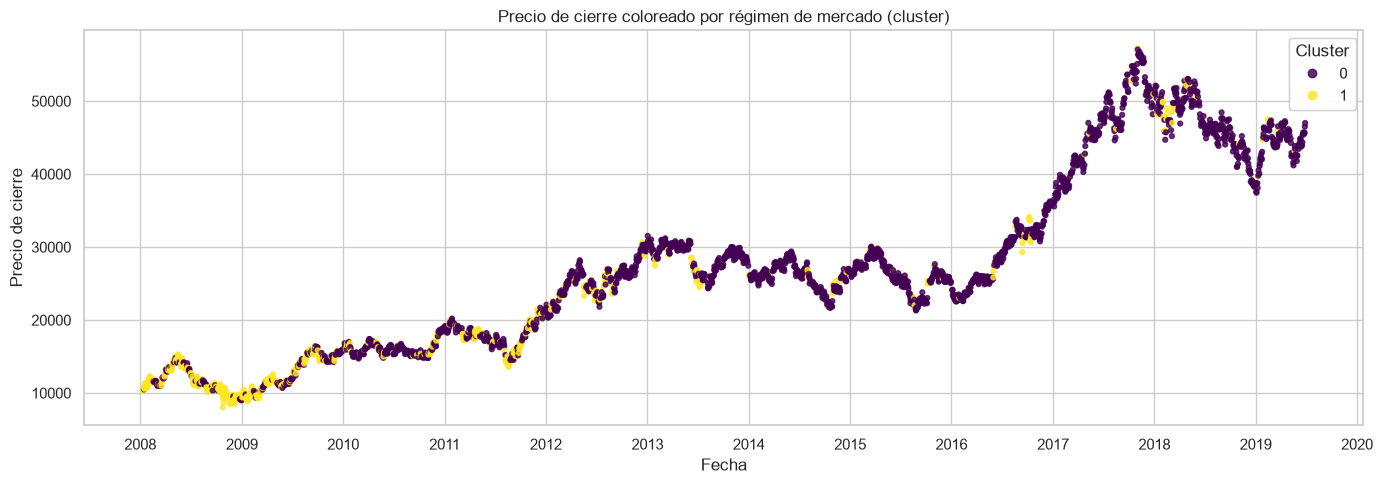

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
scatter = ax.scatter(df_features["Date"], df_features["Close"], c=df_features["cluster"],
                      cmap="viridis", s=12, alpha=0.8)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre")
ax.set_title("Precio de cierre coloreado por régimen de mercado (cluster)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig("../models/sa3_clusters_tiempo.png", dpi=110)
plt.show()

**Interpretación:** los centroides (tabla anterior) permiten nombrar cada cluster según su combinación de retorno medio, volatilidad y volumen — por ejemplo, un cluster con volatilidad alta y retorno negativo corresponde a periodos de caídas turbulentas, mientras que uno con volatilidad baja y retorno cercano a cero representa periodos de mercado calmado. La gráfica temporal muestra en qué tramos del histórico predominó cada régimen, útil para detectar visualmente periodos de crisis o estabilidad sin etiquetas externas.

## 4. Guardado del modelo

In [9]:
joblib.dump({"kmeans": final_model, "scaler": scaler, "feature_cols": feature_cols},
            "../models/sa3_kmeans_samsung.joblib")
print("Modelo guardado en models/sa3_kmeans_samsung.joblib")

Modelo guardado en models/sa3_kmeans_samsung.joblib


## 5. Conclusión

El K-Means optimizado por silueta segmenta el comportamiento diario de la acción de Samsung en regímenes de mercado distinguibles por retorno, volatilidad y volumen, sin usar ninguna etiqueta externa — un ejemplo directo de análisis no supervisado. Este enfoque complementa el análisis de agrupación clásico visto en clase (`kmeans-ventas.ipynb`) pero aplicado a series de tiempo financieras mediante ingeniería de variables previa al clustering.